# MDI3003 - Advanced Predictive Analytics
## House Price Prediction

In [41]:
!pip -q install ucimlrepo xgboost


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\MY PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [42]:
!pip install -q seaborn xgboost ucimlrepo


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\MY PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [43]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PolynomialFeatures
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import joblib,json

In [44]:
SEED=42
np.random.seed(SEED)
print(SEED)

42


In [45]:
import sklearn,platform
print(platform.python_version())
print(pd.__version__)
print(sklearn.__version__)

3.11.9
2.3.3
1.8.0


In [46]:
housing=fetch_california_housing(as_frame=True)
df=housing.frame.rename(columns={'MedHouseVal':'Price'})
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [47]:
print(df.shape)
print(df.columns)
df.info()

(20640, 9)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [48]:
audit=pd.DataFrame({'dtype':df.dtypes,'missing':df.isna().sum(),'unique':df.nunique()})
display(audit)

,dtype,missing,unique
MedInc,float64,0,12928
HouseAge,float64,0,52
AveRooms,float64,0,19392
AveBedrms,float64,0,14233
Population,float64,0,3888
AveOccup,float64,0,18841
Latitude,float64,0,862
Longitude,float64,0,844
Price,float64,0,3842


In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
Price,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [50]:
print(df.isna().sum())
print('Duplicates',df.duplicated().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64
Duplicates 0


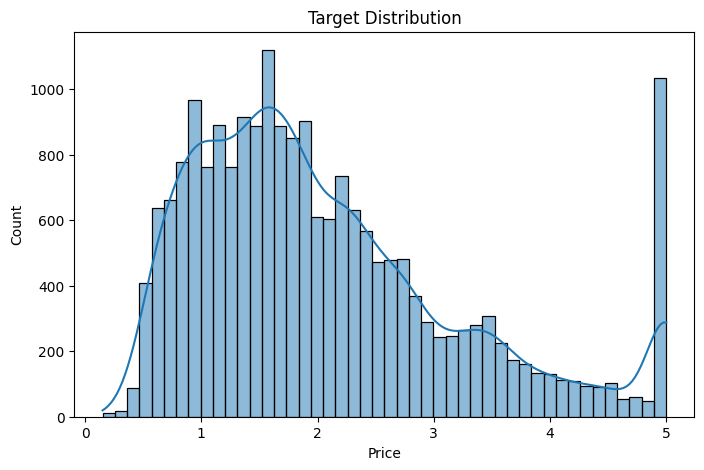

In [51]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'],kde=True)
plt.title('Target Distribution')
plt.show()

In [52]:
target='Price'
X=df.drop(columns=[target]); y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=SEED)
print(X_train.shape,X_test.shape)

(16512, 8) (4128, 8)


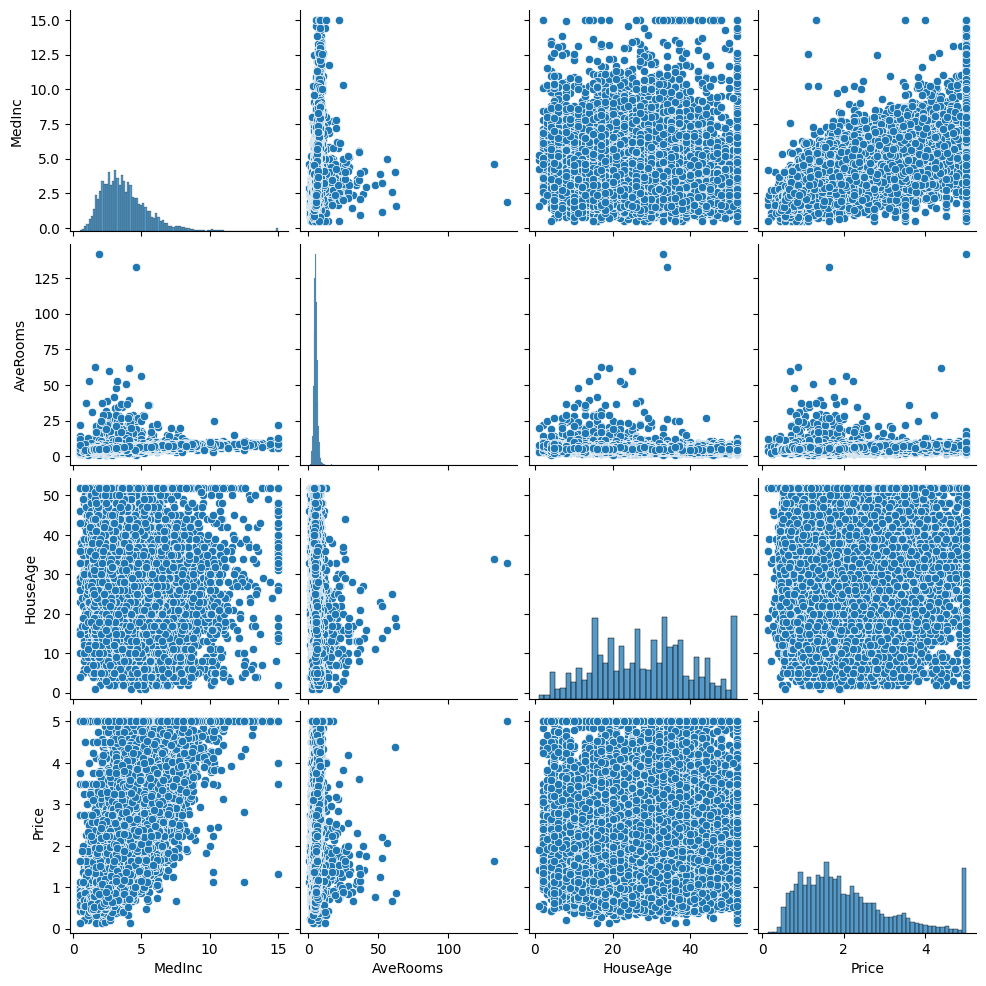

In [53]:
sns.pairplot(df[['MedInc','AveRooms','HouseAge','Price']]); plt.show()

In [54]:
num_features=X.columns.tolist();
preprocessor=ColumnTransformer([('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),num_features)])

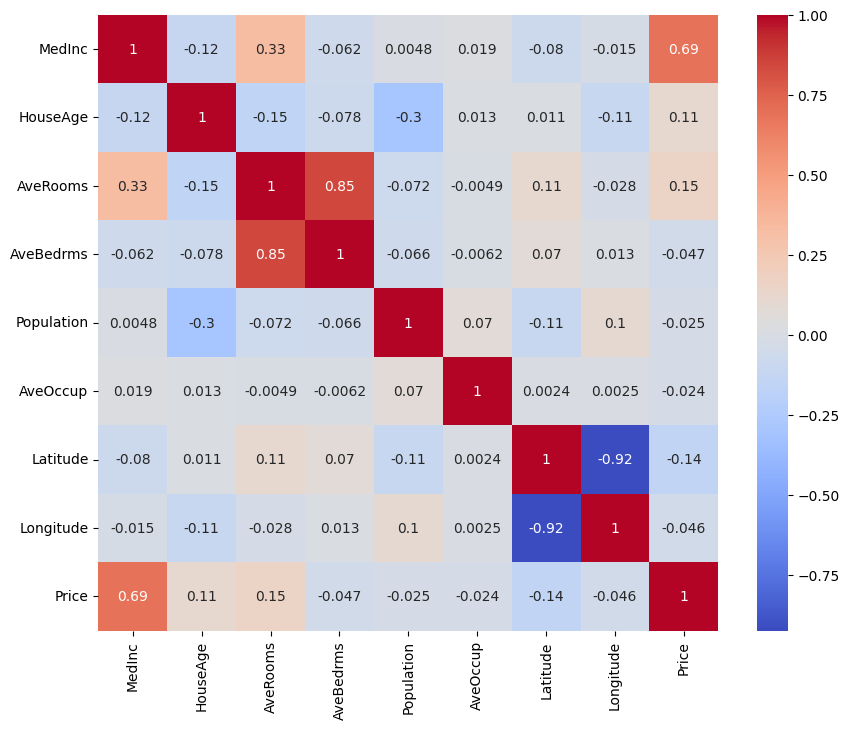

In [55]:
plt.figure(figsize=(10,8)); 
sns.heatmap(df.corr(),annot=True,cmap='coolwarm'); 
plt.show()

In [56]:
baseline=Pipeline([('prep',preprocessor),('model',DummyRegressor(strategy='mean'))]); baseline.fit(X_train,y_train); pred=baseline.predict(X_test)

In [58]:
pip install -U scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 1.3 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.3 MB 1.3 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/8.3 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.3 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.3 MB 1.3 MB/s eta 0:00:06
   -------- ------------------------------- 1.8/8.3 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.3 MB 1.3 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.3 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.6/8.3 MB 1.3 MB/s eta 0:00:05
   ------------- -------------------------- 2.9/8.3 MB 1.3 MB/s eta 0:00:05
   --------------- ------------------------ 3.1/8.3 MB 1.3 MB/s eta 0:00:04
   ---------------- ------

  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\MY PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [61]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.9060685490007149
RMSE: 1.1448563543099792
R²  : -0.00021908714592466794


In [62]:
feature='MedInc'
Xtr=X_train[[feature]]; Xte=X_test[[feature]]

In [63]:
simple=Pipeline([('scale',StandardScaler()),('model',LinearRegression())]); simple.fit(Xtr,y_train); spred=simple.predict(Xte)

In [65]:
import numpy as np

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.9060685490007149
RMSE: 1.1448563543099792
R²  : -0.00021908714592466794


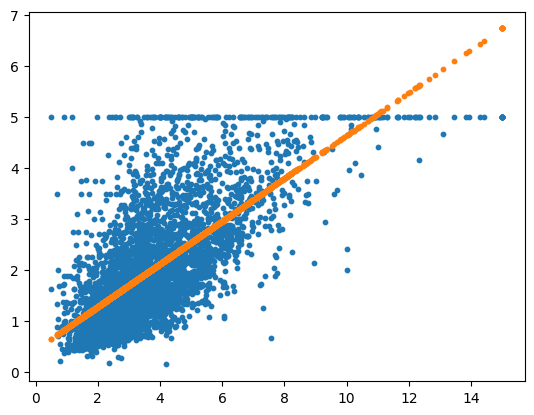

In [66]:
plt.scatter(X_test[feature],y_test,s=10); plt.scatter(X_test[feature],spred,s=10); plt.show()

In [67]:
multi=Pipeline([('prep',preprocessor),('model',LinearRegression())]); multi.fit(X_train,y_train); mpred=multi.predict(X_test)

In [69]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = pd.DataFrame({
    'Model': ['Baseline', 'Simple LR', 'Multiple LR'],
    'MAE': [
        mean_absolute_error(y_test, pred),
        mean_absolute_error(y_test, spred),
        mean_absolute_error(y_test, mpred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, pred)),
        np.sqrt(mean_squared_error(y_test, spred)),
        np.sqrt(mean_squared_error(y_test, mpred))
    ],
    'R2': [
        r2_score(y_test, pred),
        r2_score(y_test, spred),
        r2_score(y_test, mpred)
    ]
})

print(results)

         Model       MAE      RMSE        R2
0     Baseline  0.906069  1.144856 -0.000219
1    Simple LR  0.629909  0.842090  0.458859
2  Multiple LR  0.533200  0.745581  0.575788


In [70]:
## Ridge

In [72]:
import numpy as np

model = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0, random_state=SEED))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Ridge Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Ridge Regression
MAE : 0.5331931195789734
RMSE: 0.7455567442814779
R²  : 0.5758157428913684


In [73]:
## Lasso

In [75]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Lasso Regression
model = Pipeline([
    ('prep', preprocessor),
    ('model', Lasso(alpha=0.001, random_state=SEED))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("Lasso Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Lasso Regression
MAE : 0.5331447750392391
RMSE: 0.7446417662764214
R²  : 0.5768562568705682


In [76]:
## ElasticNet

In [77]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Elastic Net Regression
model = Pipeline([
    ('prep', preprocessor),
    ('model', ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=SEED))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("Elastic Net Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Elastic Net Regression
MAE : 0.5331232214464784
RMSE: 0.7449171664392671
R²  : 0.5765432059227725


In [78]:
## Decision Tree

In [79]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Decision Tree Regression
model = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=10, random_state=SEED))
])

# Train the model
model.fit(X_train, y_train)

# Predict on test data
pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("Decision Tree Regression")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Decision Tree Regression
MAE : 0.433
RMSE: 0.6442
R²  : 0.6833


In [80]:
## Random Forest

In [81]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Random Forest Regression
model = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=SEED
    ))
])

# Train the model
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("Random Forest Regression")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Random Forest Regression
MAE : 0.3274
RMSE: 0.5051
R²  : 0.8053


In [82]:
## Gradient Boosting

In [83]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting Regression
model = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=SEED))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

# Display results
print("Gradient Boosting Regression")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Gradient Boosting Regression
MAE : 0.3717
RMSE: 0.5422
R²  : 0.7756


In [84]:
# Evaluation, Tuning and Export

In [85]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(multi,X,y,cv=5,scoring='r2')
print(scores, scores.mean())

[0.54866323 0.46820691 0.55078434 0.53698703 0.66051406] 0.5530311140279563


In [86]:
params={'model__n_estimators':[100,200],'model__max_depth':[5,10]}
grid=GridSearchCV(Pipeline([('prep',preprocessor),('model',RandomForestRegressor(random_state=SEED))]),params,cv=3,scoring='r2')
grid.fit(X_train,y_train)
print(grid.best_params_,grid.best_score_)

{'model__max_depth': 10, 'model__n_estimators': 200} 0.779942399750848


In [87]:
best_model=grid.best_estimator_
pred=best_model.predict(X_test)

In [88]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

MAE : 0.3657
RMSE: 0.5431
R²  : 0.7749


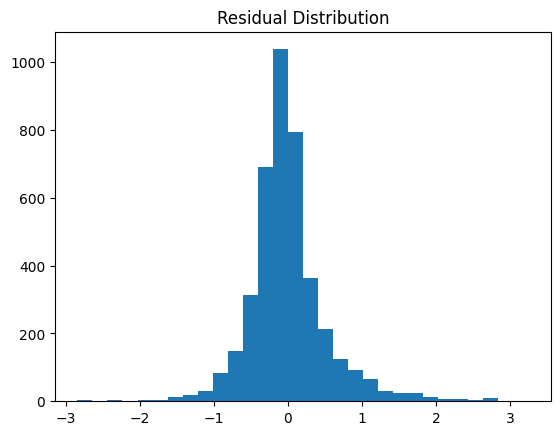

In [89]:
res=y_test-pred
plt.hist(res,bins=30); plt.title('Residual Distribution'); plt.show()

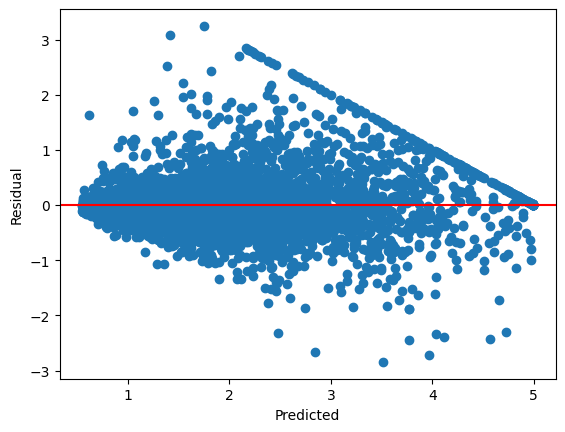

In [90]:
plt.scatter(pred,res); plt.axhline(0,color='r'); plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.show()

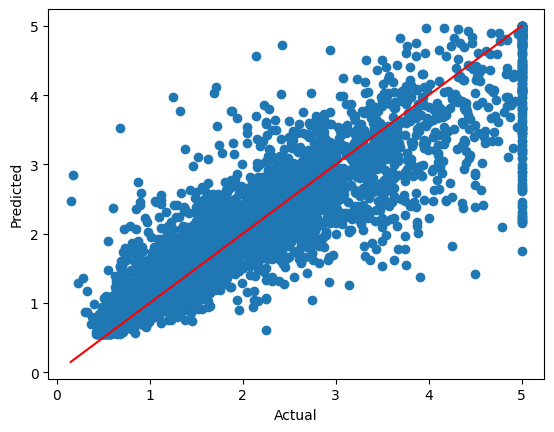

In [91]:
plt.scatter(y_test,pred); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r'); plt.show()

In [92]:
from xgboost import XGBRegressor
xgb=Pipeline([('prep',preprocessor),('model',XGBRegressor(random_state=SEED,n_estimators=200,max_depth=5,learning_rate=0.1,objective='reg:squarederror'))])
xgb.fit(X_train,y_train)
xpred=xgb.predict(X_test)
print(r2_score(y_test,xpred))

0.8283822013335888


In [93]:
joblib.dump(best_model,'best_house_price_model.joblib')

['best_house_price_model.joblib']

In [94]:
pd.DataFrame({'Actual':y_test,'Predicted':pred}).to_csv('predictions.csv',index=False)

In [95]:
import json
meta={'best_params':grid.best_params_,'r2':float(r2_score(y_test,pred))}
json.dump(meta,open('metadata.json','w'),indent=4)
print(meta)

{'best_params': {'model__max_depth': 10, 'model__n_estimators': 200}, 'r2': 0.7749077677678364}
